In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df=pd.read_csv("flood_dataset.csv")


In [ ]:
new_df=df.drop(['Unnamed: 0', 'Period', 'X_COR' , 'Y_COR' , 'LATITUDE' , 'LONGITUDE','Station Number'], axis=1)


In [ ]:
new_df.head(6)

,Station Names,YEAR,Month,Max Temp,Min Temp,Rainfall,Relative Humidity,Wind Speed,Cloud Coverage,Bright Sunshine,ALT
0,Barisal,1949,1,29.4,12.3,0.0,68.0,0.453704,0.6,7.831915,4
1,Barisal,1950,1,30.0,14.1,0.0,77.0,0.453704,0.8,7.831915,4
2,Barisal,1951,1,28.2,12.3,0.0,77.0,0.453704,0.6,7.831915,4
3,Barisal,1952,1,26.6,12.3,2.0,77.0,0.453704,1.0,7.831915,4
4,Barisal,1953,1,30.0,13.3,10.0,75.0,0.453704,1.6,7.831915,4
5,Barisal,1954,1,27.8,12.7,0.0,72.0,0.453704,0.5,7.831915,4


In [ ]:
new_df.rename(columns={'Station Names': 'District'}, inplace=True)


In [ ]:
new_df['District'].value_counts()

,count
District,
Khulna,792
Dinajpur,792
Bogra,792
Srimangal,792
Satkhira,792
Mymensingh,792
Jessore,792
Comilla,792
Cox's Bazar,792


In [ ]:
new_df.tail(5)

,District,YEAR,Month,Max Temp,Min Temp,Rainfall,Relative Humidity,Wind Speed,Cloud Coverage,Bright Sunshine,ALT
21115,Teknaf,2009,12,30.3,16.5,0.0,72.0,2.8,0.9,8.7,4
21116,Teknaf,2010,12,31.7,16.7,193.0,79.0,2.4,1.4,5.5,4
21117,Teknaf,2011,12,31.5,16.4,0.0,73.0,0.0,1.5,7.4,4
21118,Teknaf,2012,12,30.0,15.8,0.0,70.0,1.8,0.2,9.0,4
21119,Teknaf,2013,12,29.9,16.5,0.0,72.0,3.0,0.9,8.1,4


In [ ]:
Train_df = new_df[~new_df['District'].isin(['Ishurdi', 'Maijdee Court'])]

In [ ]:
Train_df['District'].value_counts()

,count
District,
Khulna,792
Dinajpur,792
Bogra,792
Srimangal,792
Satkhira,792
Mymensingh,792
Jessore,792
Comilla,792
Cox's Bazar,792


In [ ]:
df_ohe = pd.get_dummies(Train_df, columns=['District'], drop_first=True)

In [ ]:
df_ohe[df_ohe.select_dtypes(include=['bool']).columns] = df_ohe.select_dtypes(include=['bool']).astype(int)

In [ ]:
Train_df.drop(['District','YEAR'], axis=1, inplace=True)

In [ ]:
Train_df.corr()['Rainfall']

,Rainfall
Month,0.131890
Max Temp,0.263545
Min Temp,0.595328
Rainfall,1.000000
Relative Humidity,0.591652
Wind Speed,0.315075
Cloud Coverage,0.766719
Bright Sunshine,-0.668863
ALT,-0.004509


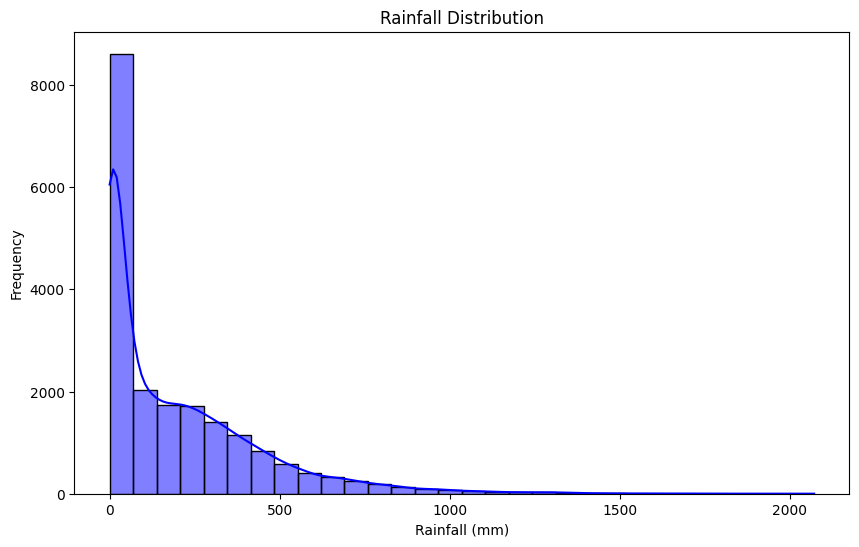

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of rainfall
plt.figure(figsize=(10, 6))
sns.histplot(Train_df['Rainfall'], kde=True, bins=30, color='blue')
plt.title('Rainfall Distribution')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Calculate percentiles to check for thresholds
threshold_90 = Train_df['Rainfall'].quantile(0.90)  # 90th percentile
threshold_95 = Train_df['Rainfall'].quantile(0.95)  # 95th percentile
threshold_99 = Train_df['Rainfall'].quantile(0.99)  # 99th percentile

print(f"90th percentile: {threshold_90}")
print(f"95th percentile: {threshold_95}")
print(f"99th percentile: {threshold_99}")


90th percentile: 512.0
95th percentile: 678.0
99th percentile: 1038.0


In [ ]:
def label_flash_flood(row, threshold=512):

    return 1 if row['Rainfall'] >= threshold else 0

# Apply the function to create the flood probability column
Train_df['Flood_Probability'] = Train_df.apply(label_flash_flood, axis=1, threshold=threshold_90)


In [ ]:
Train_df['Flood_Probability'].value_counts()

,count
Flood_Probability,
0,17745
1,1983


In [ ]:
columns_to_scale=['Max Temp', 'Min Temp', 'Rainfall', 'Relative Humidity',
                    'Wind Speed', 'Cloud Coverage', 'Bright Sunshine', 'ALT']


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
Train_df[columns_to_scale]=scaler.fit_transform(Train_df[columns_to_scale])

In [ ]:
# Apply cyclic encoding
Train_df['month_sin'] = np.sin(2 * np.pi * Train_df['Month'] / 12)
Train_df['month_cos'] = np.cos(2 * np.pi * Train_df['Month'] / 12)
Train_df.drop(columns=['Month'], inplace=True)

In [ ]:
Train_df.head()

,Max Temp,Min Temp,Rainfall,Relative Humidity,Wind Speed,Cloud Coverage,Bright Sunshine,ALT,Flood_Probability,month_sin,month_cos
0,0.349776,0.278539,0.000000,0.539683,0.040509,0.075949,0.711992,0.063492,0,0.5,0.866025
1,0.376682,0.360731,0.000000,0.682540,0.040509,0.101266,0.711992,0.063492,0,0.5,0.866025
2,0.295964,0.278539,0.000000,0.682540,0.040509,0.075949,0.711992,0.063492,0,0.5,0.866025
3,0.224215,0.278539,0.000965,0.682540,0.040509,0.126582,0.711992,0.063492,0,0.5,0.866025
4,0.376682,0.324201,0.004826,0.650794,0.040509,0.202532,0.711992,0.063492,0,0.5,0.866025


In [ ]:
features=Train_df.drop(['Flood_Probability'],axis=1)
target=Train_df['Flood_Probability']

In [ ]:
print(features.shape)
print(target.shape)

(19728, 10)
(19728,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features,target, test_size=0.3, stratify=target, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)


(13809, 10)
(5919, 10)


In [ ]:
X_train

,Max Temp,Min Temp,Rainfall,Relative Humidity,Wind Speed,Cloud Coverage,Bright Sunshine,ALT,month_sin,month_cos
5038,0.538117,0.858447,0.630309,0.873016,0.232143,0.822785,0.272727,0.063492,1.224647e-16,-1.000000e+00
9535,0.260090,0.141553,0.000000,0.761905,0.044643,0.139241,0.563636,0.111111,5.000000e-01,8.660254e-01
10494,0.569507,0.899543,0.299710,0.825397,0.294643,0.632911,0.427273,0.047619,1.224647e-16,-1.000000e+00
2654,0.475336,0.611872,0.000483,0.698413,0.089286,0.139241,0.603194,0.111111,-5.000000e-01,8.660254e-01
14945,0.869955,0.735160,0.036680,0.412698,0.223214,0.303797,0.745455,0.317460,8.660254e-01,-5.000000e-01
...,...,...,...,...,...,...,...,...,...,...
15287,0.511211,0.648402,0.013514,0.650794,0.062500,0.253165,0.727273,0.317460,-5.000000e-01,8.660254e-01
11652,0.484305,0.662100,0.010618,0.619048,0.178571,0.139241,0.845455,0.095238,1.000000e+00,6.123234e-17
2365,0.533632,0.808219,0.289093,0.777778,0.062500,0.708861,0.500000,0.111111,5.000000e-01,-8.660254e-01
6790,0.551570,0.780822,0.046815,0.761905,0.048446,0.278481,0.628727,0.587302,-8.660254e-01,5.000000e-01


In [ ]:
y_train

,Flood_Probability
5038,1
9535,0
10494,1
2654,0
14945,0
...,...
15287,0
11652,0
2365,1
6790,0


In [ ]:
X_test

,Max Temp,Min Temp,Rainfall,Relative Humidity,Wind Speed,Cloud Coverage,Bright Sunshine,ALT,month_sin,month_cos
8434,0.560538,0.831050,0.047297,0.714286,0.321429,0.443038,0.690909,0.063492,8.660254e-01,-5.000000e-01
3543,0.286996,0.429224,0.002413,0.666667,0.098214,0.151899,0.745455,0.095238,-2.449294e-16,1.000000e+00
11997,0.376682,0.255708,0.000000,0.587302,0.035714,0.164557,0.545455,0.079365,5.000000e-01,8.660254e-01
6480,0.524664,0.789954,0.078185,0.603175,0.089286,0.468354,0.622545,0.587302,5.000000e-01,-8.660254e-01
1148,0.538117,0.908676,0.233108,0.936508,0.062500,0.708861,0.172727,0.079365,-8.660254e-01,-5.000000e-01
...,...,...,...,...,...,...,...,...,...,...
14212,0.457399,0.488584,0.009170,0.746032,0.062500,0.265823,0.509091,0.301587,-5.000000e-01,8.660254e-01
15900,0.600897,0.826484,0.025579,0.730159,0.107143,0.481013,0.599663,1.000000,-8.660254e-01,5.000000e-01
4039,0.600897,0.593607,0.016892,0.587302,0.223214,0.253165,0.719284,0.158730,1.000000e+00,6.123234e-17
1506,0.721973,0.529680,0.000483,0.412698,0.125000,0.215190,0.863636,0.317460,1.000000e+00,6.123234e-17


In [ ]:
print(y_train.shape)
print(y_test.shape)
print(X_train.shape)
print(X_test.shape)

(13809,)
(5919,)
(13809, 10)
(5919, 10)


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Apply LDA
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression(class_weight='balanced')
model1=LR.fit(X_train_lda,y_train)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score
model1_pred=model1.predict(X_test_lda)
print(accuracy_score(y_test,model1_pred))
print(confusion_matrix(y_test,model1_pred))

0.9824294644365602
[[5222  102]
 [   2  593]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier(class_weight='balanced' ,random_state=42)
model2=DT.fit(X_train_lda,y_train)

In [ ]:
model2_pred=model2.predict(X_test_lda)
print(accuracy_score(y_test,model2_pred))
print(confusion_matrix(y_test,model2_pred))

0.9822605169792195
[[5276   48]
 [  57  538]]


In [ ]:
class_report=classification_report(y_test,model2_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5324
           1       0.92      0.90      0.91       595

    accuracy                           0.98      5919
   macro avg       0.95      0.95      0.95      5919
weighted avg       0.98      0.98      0.98      5919



In [ ]:
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier(class_weight='balanced',random_state=42)
model3=RF.fit(X_train_lda,y_train)

In [ ]:
model3_pred=model3.predict(X_test_lda)
print(accuracy_score(y_test,model3_pred))
print(confusion_matrix(y_test,model3_pred))

0.9822605169792195
[[5276   48]
 [  57  538]]


In [ ]:
from sklearn.svm import SVC

svm = SVC(class_weight='balanced',kernel='linear', random_state=42)
svm.fit(X_train_lda, y_train)
model4_pred = svm.predict(X_test_lda)
accuracy = accuracy_score(y_test, model4_pred)
print("Accuracy:", accuracy)
print(confusion_matrix(y_test, model4_pred))

Accuracy: 0.9815847271498563
[[5216  108]
 [   1  594]]


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, confusion_matrix

# Compute sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

ada = AdaBoostClassifier(random_state=42)


model5 = ada.fit(X_train_lda, y_train, sample_weight=sample_weights)

model5_pred = model5.predict(X_test_lda)

print("Accuracy:", accuracy_score(y_test, model5_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, model5_pred))

Accuracy: 0.9802331474911302
Confusion Matrix:
 [[5207  117]
 [   0  595]]


In [ ]:
train5_pred=model5.predict(X_train_lda)
print(accuracy_score(y_train,train5_pred))
print(confusion_matrix(y_train,train5_pred))

0.9818958650155696
[[12173   248]
 [    2  1386]]


In [ ]:
train_pred=model1.predict(X_train_lda)
print(accuracy_score(y_train,train_pred))
print(confusion_matrix(y_train,train_pred))

0.9830545296545731
[[12194   227]
 [    7  1381]]


MLP

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.metrics import accuracy_score

# Initialize the model
model = Sequential()

# Input layer with 128 units
model.add(Dense(units=128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.2))
model.add(BatchNormalization())

# Hidden layer with 64 units
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())

# Hidden layer with 32 units
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())

# Hidden layer with 16 units
model.add(Dense(units=16, activation='relu'))
model.add(Dropout(0.2))

# Output layer with sigmoid activation for binary classification
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])




In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 128)                 │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
y_train=y_train.to_numpy()


In [ ]:
# Compute class weights to handle imbalanced data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}



early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)



Epoch 1/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6961 - loss: 0.5076 - val_accuracy: 0.8890 - val_loss: 0.2563
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9193 - loss: 0.1925 - val_accuracy: 0.9552 - val_loss: 0.0924
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9409 - loss: 0.1357 - val_accuracy: 0.9838 - val_loss: 0.0486
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9367 - loss: 0.1289 - val_accuracy: 0.9726 - val_loss: 0.0629
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9503 - loss: 0.1071 - val_accuracy: 0.9708 - val_loss: 0.0637
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9623 - loss: 0.0906 - val_accuracy: 0.9627 - val_loss: 0.0916
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9655 - loss: 0.0937 - val_accuracy: 0.9856 - val_loss: 0.0315
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9660 - loss: 0.0811 - val_accuracy: 0

In [ ]:
y_train.value_counts()

,count
Flood_Probability,
0,12421
1,1388


In [ ]:
y_train.dtype

dtype('int64')

In [ ]:
loss,accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9940 - loss: 0.0139
Test Loss: 0.0147
Test Accuracy: 0.9937


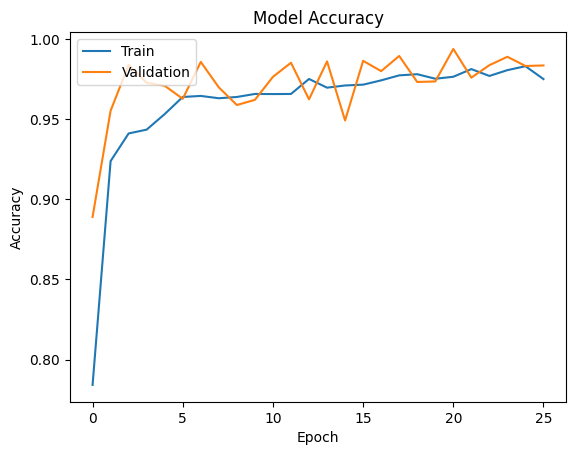

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [ ]:
# y_train=y_train.astype(int)